In [16]:
import numpy as np
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Operator, Statevector, random_statevector
from qiskit_aer import AerSimulator
from qiskit_encore.preparable_statevector import GenericQiskitPreparableStatevector

In [17]:
phi = random_statevector(64)
phi

Statevector([-0.04042633-0.01686031j,  0.05441387+0.00494464j,
              0.0508461 +0.17128589j, -0.27686046-0.02917195j,
              0.02156735-0.02569061j, -0.05155357+0.03465167j,
              0.16423964+0.07349278j,  0.06532943+0.19839501j,
              0.03837933-0.02365566j,  0.00060694+0.04523245j,
              0.07783767-0.01112014j,  0.05317759-0.07170626j,
              0.01253348-0.03238109j, -0.05504228+0.05978479j,
             -0.04430503-0.01850925j,  0.14358756-0.05415123j,
             -0.16054026+0.08106456j, -0.11478358-0.02665339j,
             -0.09028389+0.05600858j, -0.07073167-0.10427602j,
              0.00933593+0.00414447j,  0.09693151-0.16377503j,
              0.07895958+0.03446869j, -0.13248759+0.01326156j,
              0.11956934-0.02034692j,  0.05532888+0.12285815j,
             -0.07190287-0.16409659j, -0.07558233+0.01492383j,
             -0.06383494+0.12151657j, -0.19783517+0.00350403j,
              0.10135128+0.0612737j , -0.17707374+0.036

In [18]:
prep = StatePreparation(phi)
de_prep = prep.inverse()

In [19]:
prep_op = Operator(prep)
de_prep_op = prep_op.adjoint()

In [20]:
prep_gate = prep_op.to_instruction()
de_prep_gate = de_prep_op.to_instruction()

In [21]:
prep_circ = QuantumCircuit(prep_gate.num_qubits)
prep_circ.append(prep_gate, prep_circ.qubits)
de_prep_circ = QuantumCircuit(de_prep_gate.num_qubits)
de_prep_circ.append(de_prep_gate, de_prep_circ.qubits)

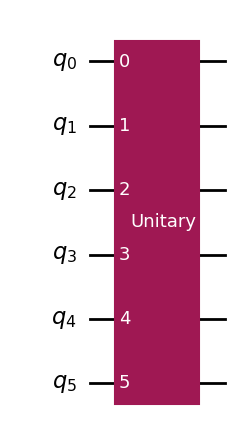

In [ ]:
prep_circ.draw("mpl")

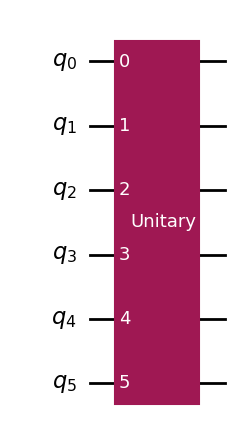

In [31]:
bigger_circ = QuantumCircuit(prep_circ.num_qubits)
bigger_circ.compose(prep_circ, bigger_circ.qubits, inplace=True)
bigger_circ.draw("mpl")

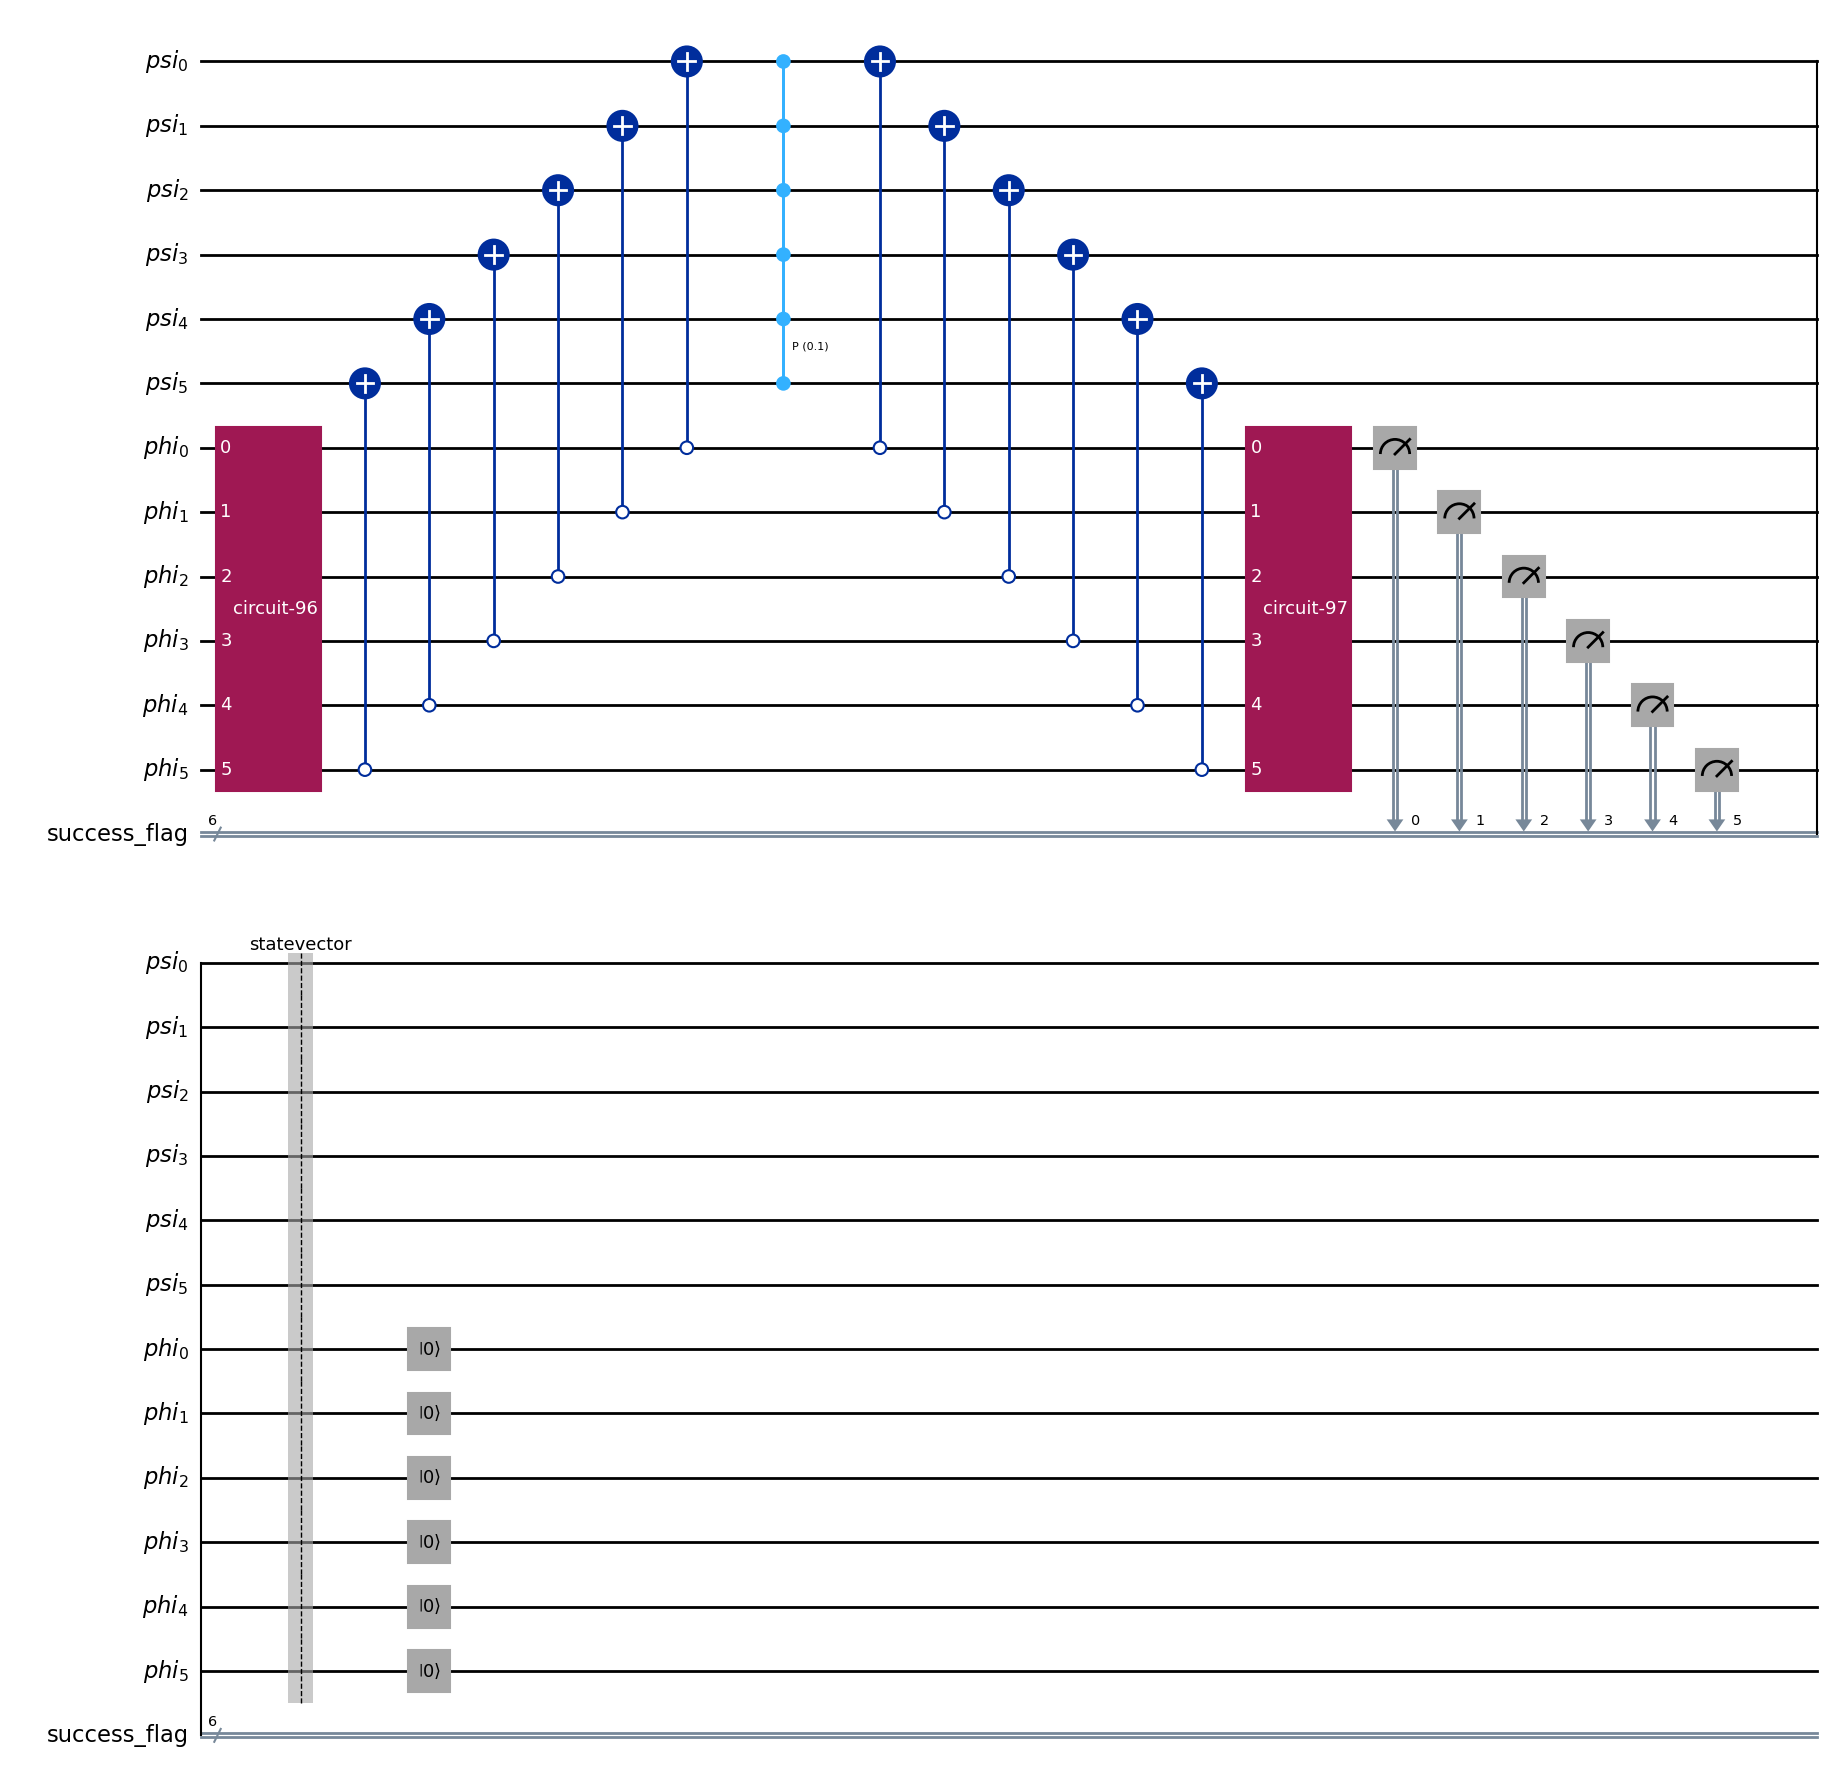

In [28]:
psi_reg = QuantumRegister(prep.num_qubits, "psi")
phi_reg = QuantumRegister(prep.num_qubits, "phi")
success_flag = ClassicalRegister(prep.num_qubits, "success_flag")
circ1 = QuantumCircuit(psi_reg, phi_reg, success_flag)

delta = 0.1

circ1.append(prep_circ, phi_reg)

# Step 2: the partial phase operator
# Flag qubit computation
for i in range(psi_reg.size):
    circ1.cx(
        phi_reg[psi_reg.size - 1 - i],
        psi_reg[psi_reg.size - 1 - i],
        ctrl_state=0,
    )

# The application of the phase
circ1.mcp(delta, psi_reg[0:-1], psi_reg[-1])

# "Un-computing" the flag qubits
for i in range(psi_reg.size):
    circ1.cx(phi_reg[i], psi_reg[i], ctrl_state=0)

# Step 3: partial measurement of the secondary register
circ1.append(de_prep_circ, phi_reg)
circ1.measure(phi_reg, success_flag)

circ1.save_statevector()

circ1.reset(phi_reg)

circ1.draw("mpl")

In [23]:
transpiled_circ1 = transpile(circ1)

In [24]:
simulator = AerSimulator(method="statevector")

In [25]:
simulator.run(transpiled_circ1).result().get_statevector()

AerError: 'unknown instruction: circuit-96'

In [ ]:
simulator.run(circ1).result().get_statevector()


Statevector([0.99999911+0.00133152j, 0.        +0.j        ,
             0.        +0.j        , ..., 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2))
